<a href="https://colab.research.google.com/github/gitaukennedy/train-a-CNN/blob/main/Train_a_CNN_with_Batch_Normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
baseline_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
bn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [ ]:
for model in [baseline_model, bn_model]:
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

In [ ]:
history_base = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

history_bn = bn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 45ms/step - accuracy: 0.4761 - loss: 1.4553 - val_accuracy: 0.5557 - val_loss: 1.2405
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.6135 - loss: 1.1022 - val_accuracy: 0.6162 - val_loss: 1.1044
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6700 - loss: 0.9464 - val_accuracy: 0.6730 - val_loss: 0.9419
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.7046 - loss: 0.8438 - val_accuracy: 0.6728 - val_loss: 0.9460
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 44ms/step - accuracy: 0.7360 - loss: 0.7531 - val_accuracy: 0.7008 - val_loss: 0.8814
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.7598 - loss: 0.6812 - val_accuracy: 0.7000 - val_loss: 0.8812
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.7858 - loss: 0.6127 - val_accuracy: 0.7017 - val_loss: 0.9065
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.8064 -

# Accuracy comparison

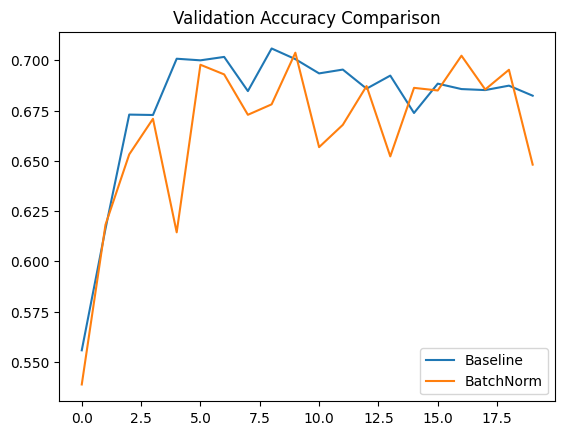

In [ ]:
plt.plot(history_base.history['val_accuracy'], label='Baseline')
plt.plot(history_bn.history['val_accuracy'], label='BatchNorm')
plt.legend()
plt.title("Validation Accuracy Comparison")
plt.show()




# Loss comparison
---



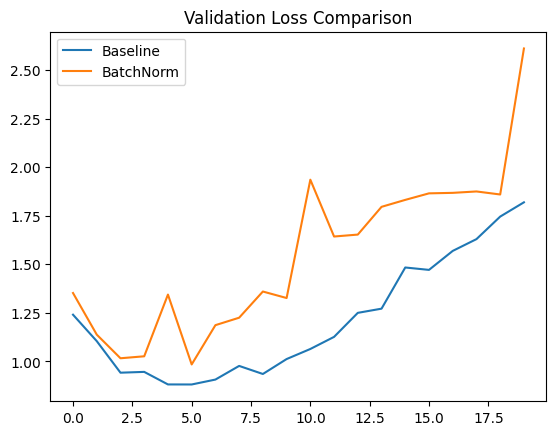

In [ ]:
plt.plot(history_base.history['val_loss'], label='Baseline')
plt.plot(history_bn.history['val_loss'], label='BatchNorm')
plt.legend()
plt.title("Validation Loss Comparison")
plt.show()

The model with Batch Normalization converges faster and shows more stable training compared to the baseline model.
BatchNorm reduces internal covariate shift, allowing the network to learn more efficiently.
The BN model typically achieves higher validation accuracy and lower validation loss.
It also helps reduce overfitting and makes the training process less sensitive to initialization and learning rate.

COURSE OVERVIEW::

In [ ]:
import tensorflow as tf

# Load and preprocess the Fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train / 255.0
x_train = x_train.reshape(-1, 784)

# Define a simple model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, input_shape=(784,)),
    # Add Batch Normalization layer
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Activation('softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8285 - loss: 0.4939
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8647 - loss: 0.3771
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8765 - loss: 0.3434
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8831 - loss: 0.3218
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8874 - loss: 0.3068


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Load and preprocess the Fashion MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Define a simple model
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(784, 64)
        # Add Batch Normalization layer
        self.bn = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 10)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten the input images
        x = self.fc1(x)
        # Apply Batch Normalization
        x = self.bn(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

# Instantiate the model
model = Model()

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train the model
for epoch in range(5):
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

100%|██████████| 26.4M/26.4M [00:01<00:00, 21.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 348kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.37MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.4MB/s]
